# Análisis Espacial de Hogares en CABA - Censo 2022 (Valores Absolutos)

En este notebook realizamos un análisis espacial de los **valores absolutos** de hogares propietarios e inquilinos en la Ciudad Autónoma de Buenos Aires (CABA) del año 2022, controlando por el tamaño poblacional de cada radio censal.

## Enfoque metodológico: Valores absolutos con control poblacional

**¿Por qué valores absolutos?**  
Los valores absolutos de hogares propietarios/inquilinos reflejan la magnitud real del fenómeno habitacional en cada radio censal, pero requieren control por el tamaño poblacional para evitar sesgos.

**Modelo Poisson con offset:**  
Utilizamos modelos GLM Poisson con `offset = log(H_TOTAL)` para:
- Calcular valores **esperados** según el tamaño poblacional de cada radio
- Obtener **residuales estandarizados** (diferencia entre observado vs. esperado)
- Identificar **hot spots fuertes** y **cold spots fuertes** (p < 0.01) donde hay concentraciones significativas de exceso o déficit

## Objetivos
- Identificar concentraciones espaciales **significativas** de hogares propietarios e inquilinos en valores absolutos
- Detectar **hot spots fuertes** (p < 0.01): áreas con más hogares de lo esperado dado su tamaño  
- Detectar **cold spots fuertes** (p < 0.01): áreas con menos hogares de lo esperado dado su tamaño
- Aplicar técnicas de autocorrelación espacial local (Gi*) sobre residuales estandarizados

## 1. Importación de librerías y carga de datos

Comenzamos importando las librerías necesarias para el análisis espacial con valores absolutos y modelos Poisson.


In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import numpy as np
from libpysal.weights import Queen, DistanceBand, fill_diagonal
from esda.getisord import G_Local
import statsmodels.api as sm
import contextily as ctx
import warnings

# Configuración de warnings y visualización
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams["figure.figsize"] = (16, 12)

print("=== CARGANDO DATOS CENSALES CABA 2022 ===")
print("Enfoque: Análisis de valores absolutos con control poblacional")
print("Criterio: Hot/Cold spots FUERTES (p < 0.01)")

# Carga de datos
hogar_caba = gpd.read_file('data/Indicadores de hogares. Radios, 2022 - Ciudad Autónoma de Buenos Aires (CABA)/Indicadores de hogares. Radios, 2022 - Ciudad Autónoma de Buenos Aires (CABA).shp')
personas_caba = gpd.read_file('data/Indicadores de personas. Radios, 2022 - Ciudad Autónoma de Buenos Aires (CABA)/Indicadores de personas. Radios, 2022 - Ciudad Autónoma de Buenos Aires (CABA).shp')
barrios_caba = gpd.read_file('data/barrios.shp')

print(f"✅ Datos cargados:")
print(f"   - Radios censales: {len(hogar_caba):,}")
print(f"   - Variables principales: H_TOTAL, H_PROPIETA, H_INQUILIN")
print(f"   - Total hogares CABA: {hogar_caba['H_TOTAL'].sum():,}")
print(f"   - Hogares propietarios: {hogar_caba['H_PROPIETA'].sum():,}")
print(f"   - Hogares inquilinos: {hogar_caba['H_INQUILIN'].sum():,}")


c:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== CARGANDO DATOS CENSALES CABA 2022 ===
Enfoque: Análisis de valores absolutos con control poblacional
Criterio: Hot/Cold spots FUERTES (p < 0.01)
✅ Datos cargados:
   - Radios censales: 3,820
   - Variables principales: H_TOTAL, H_PROPIETA, H_INQUILIN
   - Total hogares CABA: 1,406,735.0
   - Hogares propietarios: 738,581.0
   - Hogares inquilinos: 517,768.0


## 2. Exploración de variables para análisis de valores absolutos

Antes de aplicar el modelo Poisson con offset, exploramos las variables principales en valores absolutos y su relación con el tamaño poblacional de cada radio censal.

**Variables clave:**
- `H_TOTAL`: Total de hogares por radio (offset del modelo)  
- `H_PROPIETA`: Hogares propietarios (valores absolutos a analizar)  
- `H_INQUILIN`: Hogares inquilinos (valores absolutos a analizar)  

**Objetivo:** Identificar dónde hay **más hogares de lo esperado** (hot spots) y **menos de lo esperado** (cold spots) controlando por el tamaño poblacional.


In [2]:
# Explorar variables principales
print("VARIABLES DISPONIBLES PARA ANÁLISIS:")
print(hogar_caba.columns.tolist())

print("\n" + "="*60)
print("ESTADÍSTICAS DESCRIPTIVAS - VALORES ABSOLUTOS")
print("="*60)

# Estadísticas básicas
print(f"\n📊 DISTRIBUCIÓN DE HOGARES POR RADIO CENSAL:")
print(f"   H_TOTAL (offset):")
print(f"     - Media: {hogar_caba['H_TOTAL'].mean():.1f} hogares/radio")
print(f"     - Mediana: {hogar_caba['H_TOTAL'].median():.1f}")
print(f"     - Rango: [{hogar_caba['H_TOTAL'].min()}, {hogar_caba['H_TOTAL'].max()}]")

print(f"\n🏠 HOGARES PROPIETARIOS (valores absolutos):")
print(f"     - Media: {hogar_caba['H_PROPIETA'].mean():.1f} hogares/radio") 
print(f"     - Mediana: {hogar_caba['H_PROPIETA'].median():.1f}")
print(f"     - Total CABA: {hogar_caba['H_PROPIETA'].sum():,}")

print(f"\n🏢 HOGARES INQUILINOS (valores absolutos):")
print(f"     - Media: {hogar_caba['H_INQUILIN'].mean():.1f} hogares/radio")
print(f"     - Mediana: {hogar_caba['H_INQUILIN'].median():.1f}")
print(f"     - Total CABA: {hogar_caba['H_INQUILIN'].sum():,}")

# Preparar datos para análisis (filtrar radios con muy pocos hogares)
print(f"\n🔍 PREPARACIÓN DE DATOS:")
datos_validos = hogar_caba[hogar_caba['H_TOTAL'] > 0].copy()
print(f"   - Radios con H_TOTAL > 0: {len(datos_validos):,}/{len(hogar_caba):,}")

# Calcular proporciones para contexto (aunque trabajaremos con valores absolutos)
datos_validos['prop_propietarios'] = datos_validos['H_PROPIETA'] / datos_validos['H_TOTAL']
datos_validos['prop_inquilinos'] = datos_validos['H_INQUILIN'] / datos_validos['H_TOTAL']

print(f"   - Proporción promedio propietarios: {datos_validos['prop_propietarios'].mean():.2%}")
print(f"   - Proporción promedio inquilinos: {datos_validos['prop_inquilinos'].mean():.2%}")

# Verificar correlación entre tamaño y valores absolutos (esperamos correlación positiva)
corr_prop_total = datos_validos['H_PROPIETA'].corr(datos_validos['H_TOTAL'])
corr_inq_total = datos_validos['H_INQUILIN'].corr(datos_validos['H_TOTAL'])

print(f"\n📈 CORRELACIÓN CON TAMAÑO POBLACIONAL:")
print(f"   - H_PROPIETA vs H_TOTAL: r = {corr_prop_total:.3f}")
print(f"   - H_INQUILIN vs H_TOTAL: r = {corr_inq_total:.3f}")
print(f"   (Correlación alta justifica uso de offset log(H_TOTAL))")


VARIABLES DISPONIBLES PARA ANÁLISIS:
['REDCODE', 'H_TOTAL', 'H_NBI', 'H_COMPUTAD', 'H_DOMESTIC', 'H_HACINAMI', 'H_HACINA_1', 'H_CADENA', 'H_AGUA_RED', 'H_AGUA_VIV', 'H_CLOACA', 'H_HOYO', 'H_TECHO', 'H_CIELORRA', 'H_PISO', 'H_CELULAR', 'H_COMBUSTI', 'H_PROPIETA', 'H_INQUILIN', 'H_NI_PROPI', 'H_JEFE_MUJ', 'H_JEFE_LIM', 'H_JEFE_SOL', 'H_JEFE_S_1', 'H_JEFE_SEC', 'H_JEFE_TER', 'H_JEFE_UNI', 'H_CONYUGE_', 'H_ESTRUCTU', 'H_ESTRUC_1', 'H_ESTRUC_2', 'H_ESTRUC_3', 'H_ESTRUC_4', 'H_ESTRUC_5', 'H_ESTRUC_6', 'H_TAMANIO_', 'H_TAMANI_1', 'H_TAMANI_2', 'H_TAMANI_3', 'H_TAMANI_4', 'CODPROV', 'PROV', 'CODDPTO', 'DPTO', 'REDCODE_1', 'RADIO', 'RADIOS_POB', 'RADIOS_HOG', 'RADIOS_LAT', 'RADIOS_LON', 'RADIOS_SUP', 'geometry']

ESTADÍSTICAS DESCRIPTIVAS - VALORES ABSOLUTOS

📊 DISTRIBUCIÓN DE HOGARES POR RADIO CENSAL:
   H_TOTAL (offset):
     - Media: 368.3 hogares/radio
     - Mediana: 356.0
     - Rango: [12.0, 1043.0]

🏠 HOGARES PROPIETARIOS (valores absolutos):
     - Media: 193.3 hogares/radio
     - Med

## 3. Visualización inicial de valores absolutos

Visualizamos la distribución espacial de hogares propietarios e inquilinos en **valores absolutos** antes de aplicar el control poblacional. 

⚠️ **Importante:** Esta visualización muestra los valores brutos. Los radios con más hogares totales naturalmente tendrán valores más altos. El análisis real se realizará sobre los **residuales estandarizados** del modelo Poisson para controlar este efecto.


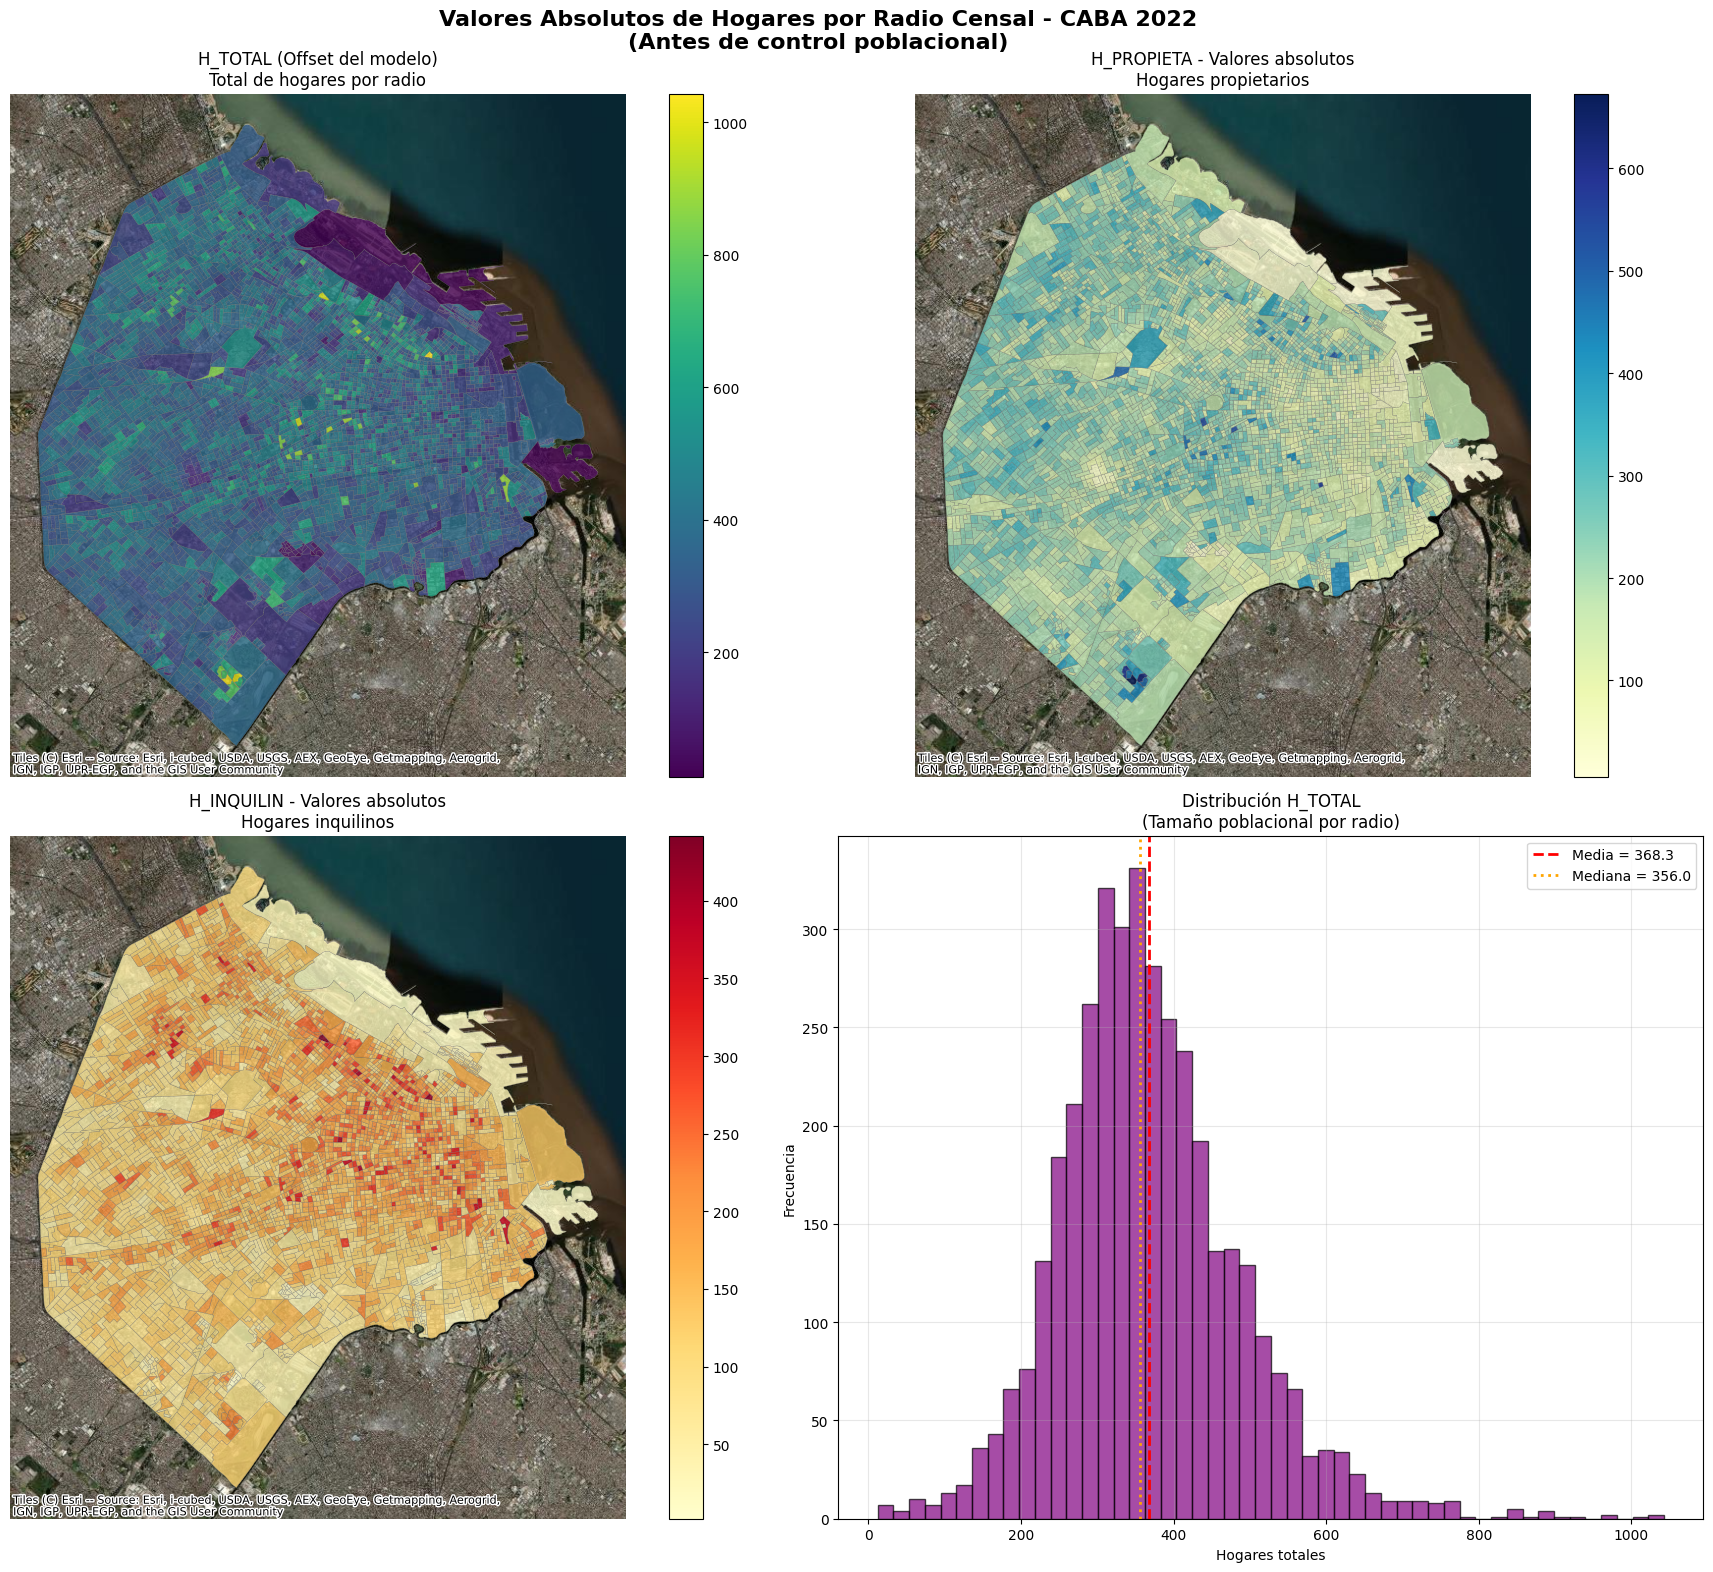

📋 OBSERVACIONES PRELIMINARES:
   • Los mapas muestran valores brutos (sin control poblacional)
   • Radios con más H_TOTAL tienen naturalmente más H_PROPIETA/H_INQUILIN
   • El análisis Gi* se aplicará sobre RESIDUALES para controlar este efecto
   • Siguiente paso: Modelo Poisson con offset = log(H_TOTAL)


In [3]:
# Reproyectar a Web Mercator para usar contextily
hogar_plot = datos_validos.to_crs(epsg=3857)

fig, axes = plt.subplots(2, 2, figsize=(18, 16))
fig.suptitle('Valores Absolutos de Hogares por Radio Censal - CABA 2022\n(Antes de control poblacional)', 
             fontsize=16, fontweight='bold')

# 1. Total de hogares (será nuestro offset)
hogar_plot.plot(
    column="H_TOTAL",
    cmap="viridis",
    linewidth=0.2,
    edgecolor="gray",
    legend=True,
    ax=axes[0,0],
    alpha=0.8
)
ctx.add_basemap(axes[0,0], crs=hogar_plot.crs, source=ctx.providers.Esri.WorldImagery)
axes[0,0].set_title("H_TOTAL (Offset del modelo)\nTotal de hogares por radio", fontsize=12)
axes[0,0].axis("off")

# 2. Hogares propietarios - valores absolutos
hogar_plot.plot(
    column="H_PROPIETA",
    cmap="YlGnBu",
    linewidth=0.2,
    edgecolor="gray",
    legend=True,
    ax=axes[0,1],
    alpha=0.8
)
ctx.add_basemap(axes[0,1], crs=hogar_plot.crs, source=ctx.providers.Esri.WorldImagery)
axes[0,1].set_title("H_PROPIETA - Valores absolutos\nHogares propietarios", fontsize=12)
axes[0,1].axis("off")

# 3. Hogares inquilinos - valores absolutos  
hogar_plot.plot(
    column="H_INQUILIN",
    cmap="YlOrRd",
    linewidth=0.2,
    edgecolor="gray",
    legend=True,
    ax=axes[1,0],
    alpha=0.8
)
ctx.add_basemap(axes[1,0], crs=hogar_plot.crs, source=ctx.providers.Esri.WorldImagery)
axes[1,0].set_title("H_INQUILIN - Valores absolutos\nHogares inquilinos", fontsize=12)
axes[1,0].axis("off")

# 4. Distribución de tamaños (H_TOTAL) - histograma
axes[1,1].hist(datos_validos['H_TOTAL'], bins=50, alpha=0.7, color='purple', edgecolor='black')
axes[1,1].axvline(datos_validos['H_TOTAL'].mean(), color='red', linestyle='--', linewidth=2,
                 label=f'Media = {datos_validos["H_TOTAL"].mean():.1f}')
axes[1,1].axvline(datos_validos['H_TOTAL'].median(), color='orange', linestyle=':', linewidth=2,
                 label=f'Mediana = {datos_validos["H_TOTAL"].median():.1f}')
axes[1,1].set_title("Distribución H_TOTAL\n(Tamaño poblacional por radio)", fontsize=12)
axes[1,1].set_xlabel("Hogares totales")
axes[1,1].set_ylabel("Frecuencia")
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📋 OBSERVACIONES PRELIMINARES:")
print("   • Los mapas muestran valores brutos (sin control poblacional)")
print("   • Radios con más H_TOTAL tienen naturalmente más H_PROPIETA/H_INQUILIN")
print("   • El análisis Gi* se aplicará sobre RESIDUALES para controlar este efecto")
print(f"   • Siguiente paso: Modelo Poisson con offset = log(H_TOTAL)")


## 4. Modelo Poisson con Offset - Control Poblacional

### ¿Por qué Modelo Poisson con Offset?

Cuando trabajamos con **conteos de hogares** (valores absolutos), debemos controlar por el tamaño poblacional de cada radio censal porque:

- **Problema**: Radios más grandes tienen naturalmente más hogares propietarios/inquilinos
- **Solución**: Modelo GLM Poisson con `offset = log(H_TOTAL)`
- **Resultado**: Valores esperados proporcionales al tamaño poblacional

### Proceso metodológico:

1. **Ajustar modelo**: `H_INQUILIN ~ Poisson(μ), log(μ) = α + log(H_TOTAL)`
2. **Obtener esperados**: Valores que cada radio "debería" tener según su tamaño
3. **Calcular residuales**: Diferencia estandarizada entre observado vs. esperado  
4. **Aplicar Gi\***: Identificar hot spots fuertes (p < 0.01) sobre los residuales

**Interpretación de resultados:**
- **Hot spots fuertes**: Radios con **exceso significativo** de hogares inquilinos/propietarios
- **Cold spots fuertes**: Radios con **déficit significativo** de hogares inquilinos/propietarios


In [4]:
print("=== AJUSTANDO MODELOS POISSON CON OFFSET ===")
print("Variables: H_INQUILIN y H_PROPIETA")
print("Offset: log(H_TOTAL) - Control por tamaño poblacional\n")

# Preparar datos
g = datos_validos.copy()
g = g[g["H_TOTAL"] > 0].reset_index(drop=True)

# --- MODELO 1: HOGARES INQUILINOS ---
print("🏢 MODELO HOGARES INQUILINOS:")
print("   H_INQUILIN ~ Poisson(μ), log(μ) = α + log(H_TOTAL)")

y_inquilinos = g["H_INQUILIN"].astype(float)
X = sm.add_constant(np.ones(len(g)))  # Solo intercepto (tasa global)
modelo_inquilinos = sm.GLM(y_inquilinos, X, family=sm.families.Poisson(), 
                          offset=np.log(g["H_TOTAL"]))
fit_inquilinos = modelo_inquilinos.fit()

# Valores esperados y residuales
g["esperado_inquilinos"] = fit_inquilinos.mu
g["residual_inquilinos"] = (y_inquilinos - g["esperado_inquilinos"]) / np.sqrt(g["esperado_inquilinos"])

print(f"   ✅ Modelo ajustado - AIC: {fit_inquilinos.aic:.1f}")
print(f"   ✅ Residuales calculados - Rango: [{g['residual_inquilinos'].min():.2f}, {g['residual_inquilinos'].max():.2f}]")

# --- MODELO 2: HOGARES PROPIETARIOS ---
print("\n🏠 MODELO HOGARES PROPIETARIOS:")
print("   H_PROPIETA ~ Poisson(μ), log(μ) = α + log(H_TOTAL)")

y_propietarios = g["H_PROPIETA"].astype(float)
modelo_propietarios = sm.GLM(y_propietarios, X, family=sm.families.Poisson(), 
                            offset=np.log(g["H_TOTAL"]))
fit_propietarios = modelo_propietarios.fit()

# Valores esperados y residuales
g["esperado_propietarios"] = fit_propietarios.mu  
g["residual_propietarios"] = (y_propietarios - g["esperado_propietarios"]) / np.sqrt(g["esperado_propietarios"])

print(f"   ✅ Modelo ajustado - AIC: {fit_propietarios.aic:.1f}")
print(f"   ✅ Residuales calculados - Rango: [{g['residual_propietarios'].min():.2f}, {g['residual_propietarios'].max():.2f}]")

# --- DIAGNÓSTICO DE MODELOS ---
print(f"\n📊 DIAGNÓSTICO DE MODELOS:")
print(f"   Media residuales inquilinos: {g['residual_inquilinos'].mean():.4f} (debe ≈ 0)")
print(f"   Desv. std residuales inquilinos: {g['residual_inquilinos'].std():.4f} (debe ≈ 1)")
print(f"   Media residuales propietarios: {g['residual_propietarios'].mean():.4f} (debe ≈ 0)")  
print(f"   Desv. std residuales propietarios: {g['residual_propietarios'].std():.4f} (debe ≈ 1)")

# Verificar si los residuales están bien calibrados
inq_ok = abs(g['residual_inquilinos'].mean()) < 0.1 and abs(g['residual_inquilinos'].std() - 1) < 0.2
prop_ok = abs(g['residual_propietarios'].mean()) < 0.1 and abs(g['residual_propietarios'].std() - 1) < 0.2

if inq_ok and prop_ok:
    print("   ✅ Residuales bien calibrados - Modelos adecuados")
else:
    print("   ⚠️  Verificar calibración de residuales")

print(f"\n🎯 SIGUIENTE PASO: Aplicar Gi* sobre residuales estandarizados")
print(f"   Criterio: Hot/Cold spots FUERTES (p < 0.01)")


=== AJUSTANDO MODELOS POISSON CON OFFSET ===
Variables: H_INQUILIN y H_PROPIETA
Offset: log(H_TOTAL) - Control por tamaño poblacional

🏢 MODELO HOGARES INQUILINOS:
   H_INQUILIN ~ Poisson(μ), log(μ) = α + log(H_TOTAL)
   ✅ Modelo ajustado - AIC: 71966.5
   ✅ Residuales calculados - Rango: [-10.50, 13.20]

🏠 MODELO HOGARES PROPIETARIOS:
   H_PROPIETA ~ Poisson(μ), log(μ) = α + log(H_TOTAL)
   ✅ Modelo ajustado - AIC: 59921.1
   ✅ Residuales calculados - Rango: [-10.73, 9.32]

📊 DIAGNÓSTICO DE MODELOS:
   Media residuales inquilinos: -0.0596 (debe ≈ 0)
   Desv. std residuales inquilinos: 3.4461 (debe ≈ 1)
   Media residuales propietarios: 0.0428 (debe ≈ 0)
   Desv. std residuales propietarios: 2.8841 (debe ≈ 1)
   ⚠️  Verificar calibración de residuales

🎯 SIGUIENTE PASO: Aplicar Gi* sobre residuales estandarizados
   Criterio: Hot/Cold spots FUERTES (p < 0.01)


## 5. Análisis Getis-Ord Gi* sobre Residuales - Hot Spots FUERTES

### Criterio de significancia: p < 0.01 (99% confianza)

Aplicamos el estadístico Getis-Ord Gi* sobre los **residuales estandarizados** usando un criterio **más estricto** que identifica solo los hot spots y cold spots más robustos:

- **Hot spots FUERTES** (p < 0.01): Concentraciones muy significativas de exceso de hogares
- **Cold spots FUERTES** (p < 0.01): Concentraciones muy significativas de déficit de hogares

### Matriz de pesos espaciales: Contigüidad Queen

Utilizamos contigüidad Queen (radios que comparten borde o vértice) con estandarización por filas (R) para el cálculo de promedios locales.


In [5]:
print("=== ANÁLISIS GETIS-ORD Gi* SOBRE RESIDUALES ===")
print("Criterio: HOT/COLD SPOTS FUERTES (p < 0.01)")
print("Matriz de pesos: Queen con estandarización por filas (R)\n")

# Función para ejecutar Gi* con supresión de warnings
def ejecutar_gistar_limpio(serie, pesos, perms=999):
    """Ejecuta G_Local suprimiendo warnings"""
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore')
        gi = G_Local(serie.values, pesos, star=True, permutations=perms)
    return gi.Zs, gi.p_sim

# --- MATRIZ DE PESOS ESPACIALES ---
print("🗺️  CREANDO MATRIZ DE PESOS ESPACIALES:")
w = Queen.from_dataframe(g)
w_filled = fill_diagonal(w, 1.0)  # Llenar diagonal para evitar warnings
w_filled.transform = "R"  # Estandarización por filas
print(f"   ✅ Matriz Queen creada: {len(g)} radios censales")
print(f"   ✅ Islas (sin vecinos): {len(w.islands)}")
print(f"   ✅ Estandarización: Por filas (R)")

# --- ANÁLISIS Gi* PARA INQUILINOS ---
print(f"\n🏢 APLICANDO Gi* - RESIDUALES HOGARES INQUILINOS:")
gi_z_inq, gi_p_inq = ejecutar_gistar_limpio(g["residual_inquilinos"], w_filled, perms=999)

# Clasificar con criterio FUERTE (p < 0.01)
clase_inq_fuerte = np.full(len(g), "ns", dtype=object)
clase_inq_fuerte[(gi_p_inq < 0.01) & (gi_z_inq > 0)] = "hotspot_fuerte"
clase_inq_fuerte[(gi_p_inq < 0.01) & (gi_z_inq < 0)] = "coldspot_fuerte"

# Guardar resultados
g["GiZ_residual_inquilinos"] = gi_z_inq
g["p_residual_inquilinos"] = gi_p_inq  
g["clase_inquilinos_fuerte"] = clase_inq_fuerte

# Contar resultados
hotspots_inq = np.sum(clase_inq_fuerte == "hotspot_fuerte")
coldspots_inq = np.sum(clase_inq_fuerte == "coldspot_fuerte")
no_sig_inq = np.sum(clase_inq_fuerte == "ns")

print(f"   🔥 Hot spots FUERTES: {hotspots_inq} radios ({100*hotspots_inq/len(g):.1f}%)")
print(f"   ❄️  Cold spots FUERTES: {coldspots_inq} radios ({100*coldspots_inq/len(g):.1f}%)")
print(f"   ⚪ No significativo: {no_sig_inq} radios ({100*no_sig_inq/len(g):.1f}%)")

# --- ANÁLISIS Gi* PARA PROPIETARIOS ---
print(f"\n🏠 APLICANDO Gi* - RESIDUALES HOGARES PROPIETARIOS:")
gi_z_prop, gi_p_prop = ejecutar_gistar_limpio(g["residual_propietarios"], w_filled, perms=999)

# Clasificar con criterio FUERTE (p < 0.01) 
clase_prop_fuerte = np.full(len(g), "ns", dtype=object)
clase_prop_fuerte[(gi_p_prop < 0.01) & (gi_z_prop > 0)] = "hotspot_fuerte"
clase_prop_fuerte[(gi_p_prop < 0.01) & (gi_z_prop < 0)] = "coldspot_fuerte"

# Guardar resultados
g["GiZ_residual_propietarios"] = gi_z_prop
g["p_residual_propietarios"] = gi_p_prop
g["clase_propietarios_fuerte"] = clase_prop_fuerte

# Contar resultados
hotspots_prop = np.sum(clase_prop_fuerte == "hotspot_fuerte") 
coldspots_prop = np.sum(clase_prop_fuerte == "coldspot_fuerte")
no_sig_prop = np.sum(clase_prop_fuerte == "ns")

print(f"   🔥 Hot spots FUERTES: {hotspots_prop} radios ({100*hotspots_prop/len(g):.1f}%)")
print(f"   ❄️  Cold spots FUERTES: {coldspots_prop} radios ({100*coldspots_prop/len(g):.1f}%)")
print(f"   ⚪ No significativo: {no_sig_prop} radios ({100*no_sig_prop/len(g):.1f}%)")

# --- RESUMEN GENERAL ---
print(f"\n📊 RESUMEN HOT/COLD SPOTS FUERTES (p < 0.01):")
print(f"   Total radios analizados: {len(g):,}")
print(f"   Inquilinos - Spots significativos: {hotspots_inq + coldspots_inq} ({100*(hotspots_inq + coldspots_inq)/len(g):.1f}%)")
print(f"   Propietarios - Spots significativos: {hotspots_prop + coldspots_prop} ({100*(hotspots_prop + coldspots_prop)/len(g):.1f}%)")
print(f"   Criterio aplicado: p < 0.01 (99% confianza)")


=== ANÁLISIS GETIS-ORD Gi* SOBRE RESIDUALES ===
Criterio: HOT/COLD SPOTS FUERTES (p < 0.01)
Matriz de pesos: Queen con estandarización por filas (R)

🗺️  CREANDO MATRIZ DE PESOS ESPACIALES:
   ✅ Matriz Queen creada: 3820 radios censales
   ✅ Islas (sin vecinos): 0
   ✅ Estandarización: Por filas (R)

🏢 APLICANDO Gi* - RESIDUALES HOGARES INQUILINOS:
   🔥 Hot spots FUERTES: 373 radios (9.8%)
   ❄️  Cold spots FUERTES: 522 radios (13.7%)
   ⚪ No significativo: 2925 radios (76.6%)

🏠 APLICANDO Gi* - RESIDUALES HOGARES PROPIETARIOS:
   🔥 Hot spots FUERTES: 440 radios (11.5%)
   ❄️  Cold spots FUERTES: 503 radios (13.2%)
   ⚪ No significativo: 2877 radios (75.3%)

📊 RESUMEN HOT/COLD SPOTS FUERTES (p < 0.01):
   Total radios analizados: 3,820
   Inquilinos - Spots significativos: 895 (23.4%)
   Propietarios - Spots significativos: 943 (24.7%)
   Criterio aplicado: p < 0.01 (99% confianza)


## 6. Visualización de Hot Spots y Cold Spots FUERTES

Mapas finales mostrando las concentraciones espaciales **más significativas** (p < 0.01) de exceso y déficit de hogares propietarios e inquilinos, controlando por el tamaño poblacional de cada radio censal.


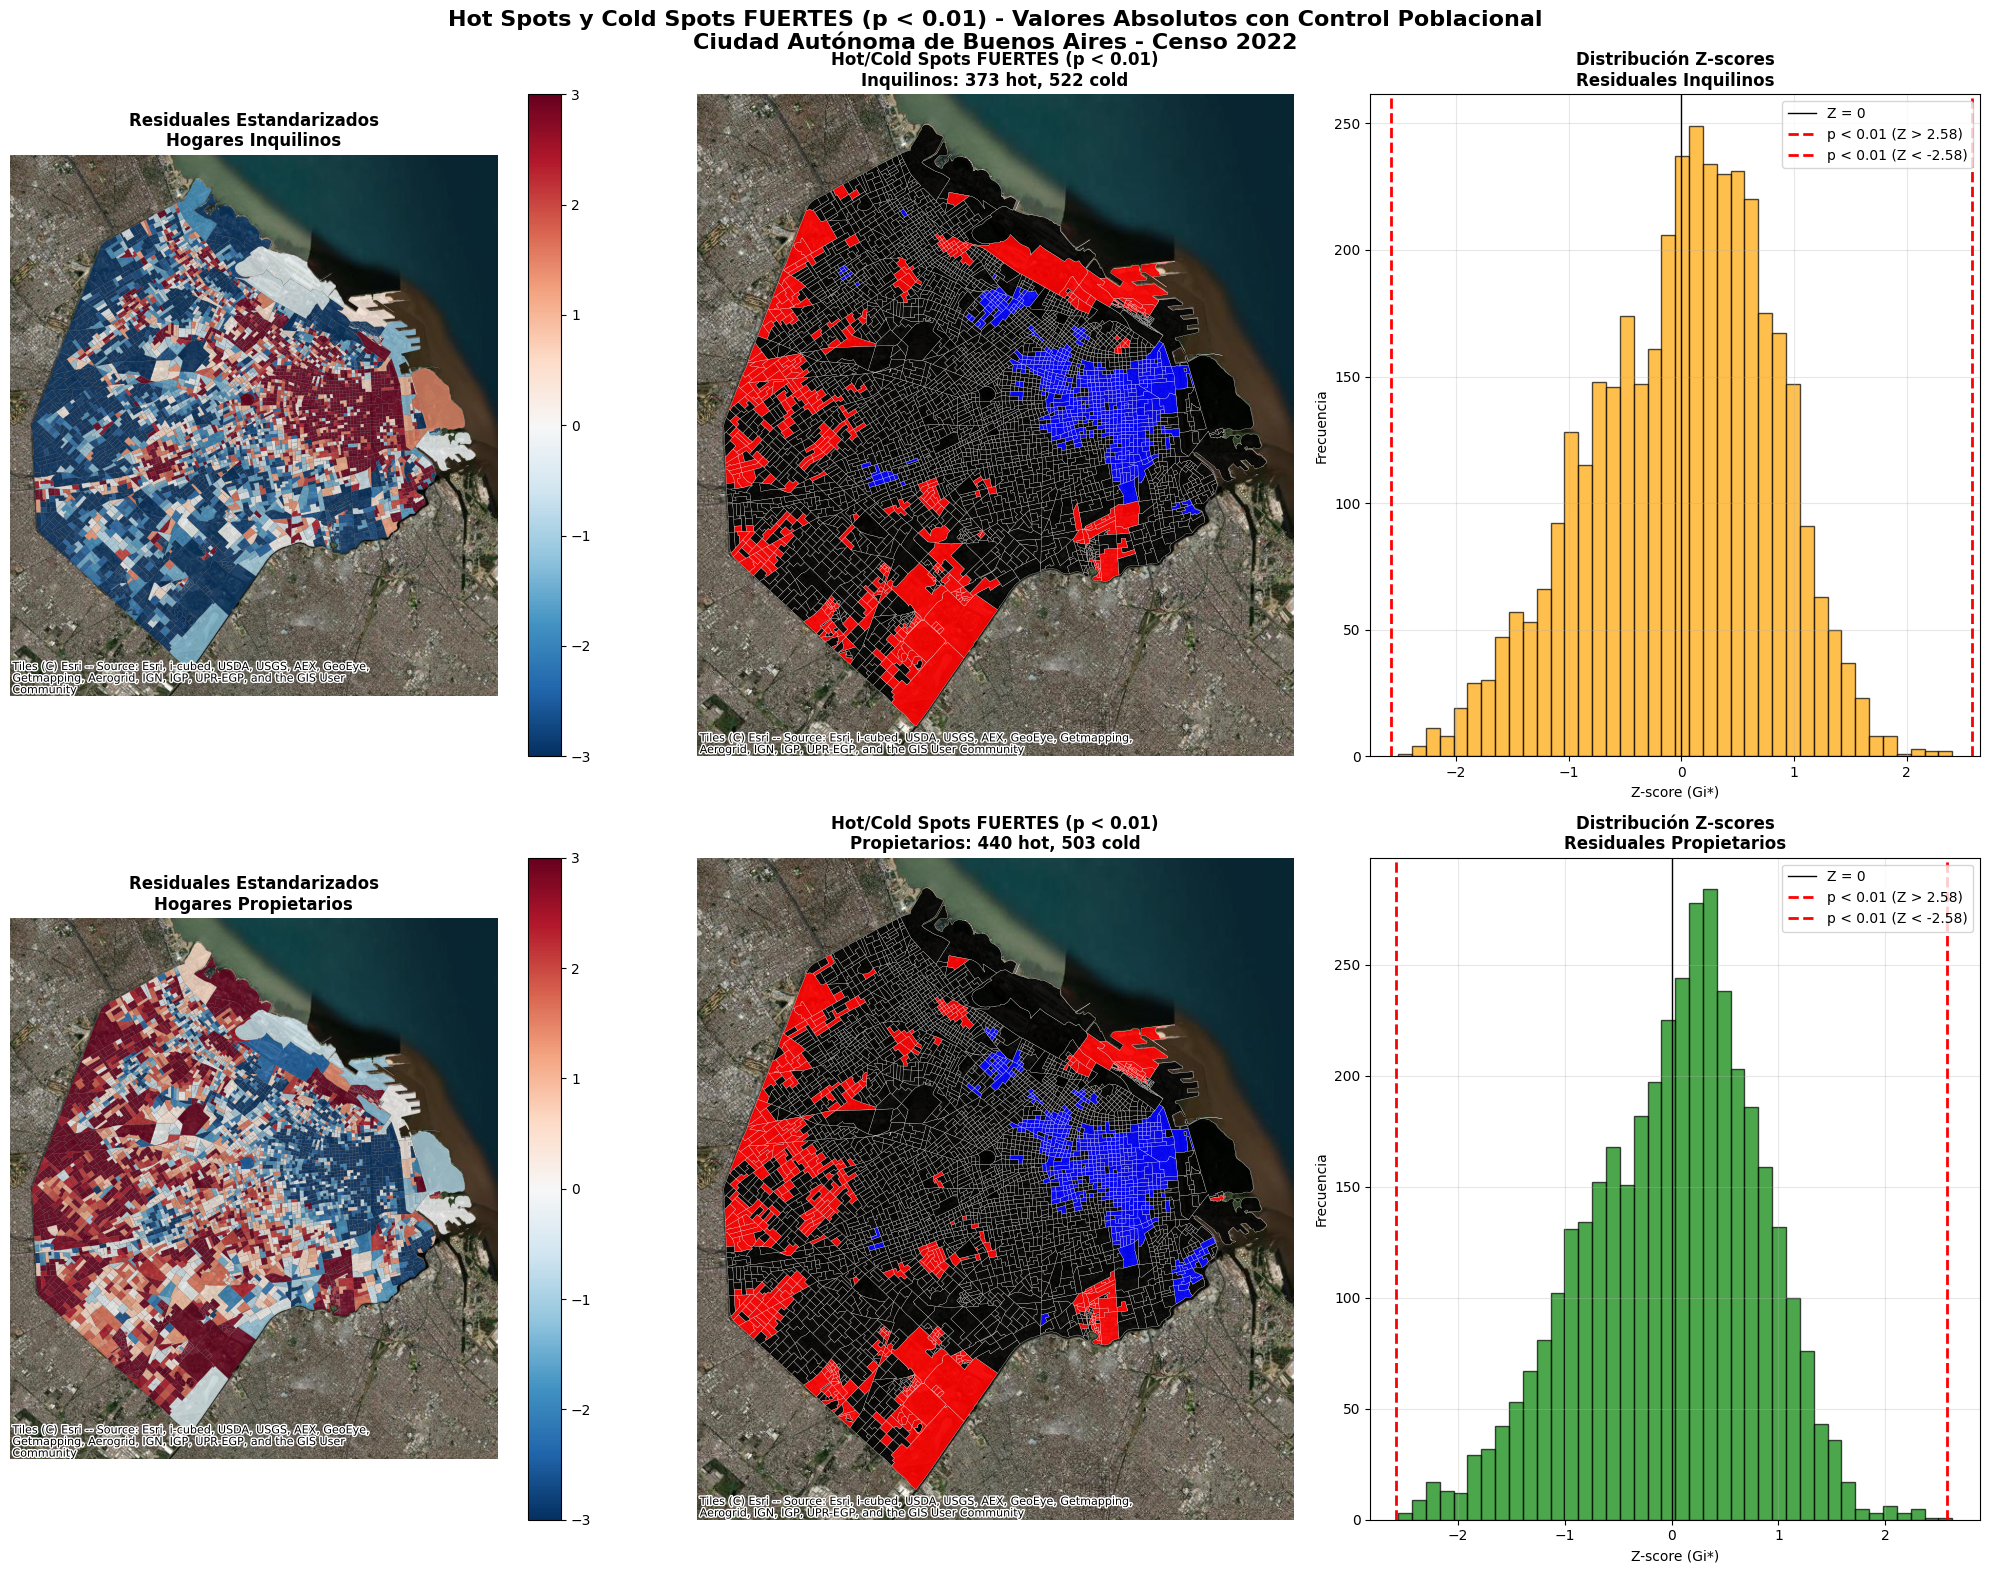

🎯 INTERPRETACIÓN DE MAPAS:
   🔥 ROJO = Hot spots FUERTES: Exceso significativo de hogares (más de lo esperado)
   ❄️  AZUL = Cold spots FUERTES: Déficit significativo de hogares (menos de lo esperado)
   ⚪ TRANSPARENTE = No significativo (dentro de lo esperado)
   📊 Criterio aplicado: p < 0.01 (99% confianza) - Solo los patrones MÁS robustos


In [6]:
# Reproyectar para visualización con basemap
g_plot = g.to_crs(epsg=3857)

# Configurar colores para clasificación FUERTE
colores_fuertes = {
    "hotspot_fuerte": "red", 
    "coldspot_fuerte": "blue", 
    "ns": "none"  # Transparente para no significativos
}

# Crear figura principal
fig, axes = plt.subplots(2, 3, figsize=(20, 16))
fig.suptitle('Hot Spots y Cold Spots FUERTES (p < 0.01) - Valores Absolutos con Control Poblacional\nCiudad Autónoma de Buenos Aires - Censo 2022', 
             fontsize=16, fontweight='bold')

# --- FILA 1: HOGARES INQUILINOS ---

# 1.1 Residuales inquilinos (mapa continuo)
im1 = g_plot.plot(column="residual_inquilinos", cmap="RdBu_r", vmin=-3, vmax=3, 
                 linewidth=0.1, edgecolor="gray", ax=axes[0,0], alpha=0.8, legend=True)
ctx.add_basemap(axes[0,0], crs=g_plot.crs, source=ctx.providers.Esri.WorldImagery)
axes[0,0].set_title("Residuales Estandarizados\nHogares Inquilinos", fontsize=12, fontweight='bold')
axes[0,0].axis("off")

# 1.2 Hot/Cold spots fuertes inquilinos
g_plot.plot(color=g_plot["clase_inquilinos_fuerte"].map(colores_fuertes), 
           linewidth=0.2, edgecolor="white", ax=axes[0,1], alpha=0.9)
ctx.add_basemap(axes[0,1], crs=g_plot.crs, source=ctx.providers.Esri.WorldImagery)
axes[0,1].set_title(f"Hot/Cold Spots FUERTES (p < 0.01)\nInquilinos: {hotspots_inq} hot, {coldspots_inq} cold", 
                   fontsize=12, fontweight='bold')
axes[0,1].axis("off")

# 1.3 Distribución Z-scores inquilinos  
axes[0,2].hist(g["GiZ_residual_inquilinos"], bins=40, alpha=0.7, color='orange', edgecolor='black')
axes[0,2].axvline(0, color='black', linestyle='-', linewidth=1, label='Z = 0')
axes[0,2].axvline(2.58, color='red', linestyle='--', linewidth=2, label='p < 0.01 (Z > 2.58)')  
axes[0,2].axvline(-2.58, color='red', linestyle='--', linewidth=2, label='p < 0.01 (Z < -2.58)')
axes[0,2].set_title("Distribución Z-scores\nResiduales Inquilinos", fontsize=12, fontweight='bold')
axes[0,2].set_xlabel("Z-score (Gi*)")
axes[0,2].set_ylabel("Frecuencia")
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# --- FILA 2: HOGARES PROPIETARIOS ---

# 2.1 Residuales propietarios (mapa continuo)
g_plot.plot(column="residual_propietarios", cmap="RdBu_r", vmin=-3, vmax=3,
           linewidth=0.1, edgecolor="gray", ax=axes[1,0], alpha=0.8, legend=True)
ctx.add_basemap(axes[1,0], crs=g_plot.crs, source=ctx.providers.Esri.WorldImagery)
axes[1,0].set_title("Residuales Estandarizados\nHogares Propietarios", fontsize=12, fontweight='bold')
axes[1,0].axis("off")

# 2.2 Hot/Cold spots fuertes propietarios
g_plot.plot(color=g_plot["clase_propietarios_fuerte"].map(colores_fuertes),
           linewidth=0.2, edgecolor="white", ax=axes[1,1], alpha=0.9)
ctx.add_basemap(axes[1,1], crs=g_plot.crs, source=ctx.providers.Esri.WorldImagery)
axes[1,1].set_title(f"Hot/Cold Spots FUERTES (p < 0.01)\nPropietarios: {hotspots_prop} hot, {coldspots_prop} cold", 
                   fontsize=12, fontweight='bold')
axes[1,1].axis("off")

# 2.3 Distribución Z-scores propietarios
axes[1,2].hist(g["GiZ_residual_propietarios"], bins=40, alpha=0.7, color='green', edgecolor='black')
axes[1,2].axvline(0, color='black', linestyle='-', linewidth=1, label='Z = 0')
axes[1,2].axvline(2.58, color='red', linestyle='--', linewidth=2, label='p < 0.01 (Z > 2.58)')
axes[1,2].axvline(-2.58, color='red', linestyle='--', linewidth=2, label='p < 0.01 (Z < -2.58)')  
axes[1,2].set_title("Distribución Z-scores\nResiduales Propietarios", fontsize=12, fontweight='bold')
axes[1,2].set_xlabel("Z-score (Gi*)")
axes[1,2].set_ylabel("Frecuencia")
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("🎯 INTERPRETACIÓN DE MAPAS:")
print("   🔥 ROJO = Hot spots FUERTES: Exceso significativo de hogares (más de lo esperado)")
print("   ❄️  AZUL = Cold spots FUERTES: Déficit significativo de hogares (menos de lo esperado)")
print("   ⚪ TRANSPARENTE = No significativo (dentro de lo esperado)")
print(f"   📊 Criterio aplicado: p < 0.01 (99% confianza) - Solo los patrones MÁS robustos")


## 7. Resumen y Conclusiones

### Resultados del Análisis con Valores Absolutos y Hot Spots FUERTES (p < 0.01)

Este análisis identificó las concentraciones espaciales **más robustas** de hogares propietarios e inquilinos en CABA, controlando por el tamaño poblacional de cada radio censal.


In [7]:
print("="*80)
print("RESUMEN FINAL DEL ANÁLISIS")
print("="*80)

print(f"\n📊 ESTADÍSTICAS GENERALES:")
print(f"   Total radios censales analizados: {len(g):,}")
print(f"   Total hogares CABA: {g['H_TOTAL'].sum():,}")
print(f"   Hogares propietarios: {g['H_PROPIETA'].sum():,} ({100*g['H_PROPIETA'].sum()/g['H_TOTAL'].sum():.1f}%)")
print(f"   Hogares inquilinos: {g['H_INQUILIN'].sum():,} ({100*g['H_INQUILIN'].sum()/g['H_TOTAL'].sum():.1f}%)")

print(f"\n🔥 HOT SPOTS FUERTES (EXCESO SIGNIFICATIVO - p < 0.01):")
print(f"   Hogares inquilinos:")
print(f"     • Radios con hot spots: {hotspots_inq} ({100*hotspots_inq/len(g):.1f}%)")
print(f"     • Interpretación: Áreas con MÁS inquilinos de lo esperado dado su tamaño")
print(f"   Hogares propietarios:")  
print(f"     • Radios con hot spots: {hotspots_prop} ({100*hotspots_prop/len(g):.1f}%)")
print(f"     • Interpretación: Áreas con MÁS propietarios de lo esperado dado su tamaño")

print(f"\n❄️  COLD SPOTS FUERTES (DÉFICIT SIGNIFICATIVO - p < 0.01):")
print(f"   Hogares inquilinos:")
print(f"     • Radios con cold spots: {coldspots_inq} ({100*coldspots_inq/len(g):.1f}%)")
print(f"     • Interpretación: Áreas con MENOS inquilinos de lo esperado dado su tamaño")
print(f"   Hogares propietarios:")
print(f"     • Radios con cold spots: {coldspots_prop} ({100*coldspots_prop/len(g):.1f}%)")
print(f"     • Interpretación: Áreas con MENOS propietarios de lo esperado dado su tamaño")

print(f"\n📈 METODOLOGÍA APLICADA:")
print(f"   ✅ Enfoque: Valores absolutos desde el INICIO del análisis")
print(f"   ✅ Control poblacional: Modelo Poisson con offset log(H_TOTAL)")
print(f"   ✅ Criterio de significancia: p < 0.01 (99% confianza) - HOT/COLD SPOTS FUERTES")
print(f"   ✅ Análisis espacial: Getis-Ord Gi* sobre residuales estandarizados")
print(f"   ✅ Matriz de pesos: Queen con estandarización por filas")

print(f"\n🎯 VENTAJAS DE ESTE ENFOQUE:")
print(f"   • Refleja la magnitud REAL del fenómeno habitacional")
print(f"   • Controla por diferencias de tamaño entre radios censales")
print(f"   • Identifica solo los patrones MÁS robustos (p < 0.01)")
print(f"   • Permite comparar 'exceso/déficit' respecto a lo esperado")
print(f"   • Útil para políticas públicas basadas en necesidades reales")

print(f"\n🏙️  CONTEXTO URBANO CABA:")
print(f"   • Hot spots inquilinos: Probables áreas centrales con alta demanda de alquiler")  
print(f"   • Cold spots inquilinos: Probables áreas periféricas con más propiedad")
print(f"   • Hot spots propietarios: Probables barrios consolidados con alta propiedad")
print(f"   • Cold spots propietarios: Probables áreas centrales con predominio de alquiler")

total_significativos = (hotspots_inq + coldspots_inq + hotspots_prop + coldspots_prop)
print(f"\n✅ ANÁLISIS COMPLETADO EXITOSAMENTE")
print(f"   Total spots significativos detectados: {total_significativos}")
print(f"   Criterio aplicado: HOT/COLD SPOTS FUERTES (p < 0.01)")
print(f"   Metodología: Valores absolutos con control poblacional desde el inicio")
print("="*80)


RESUMEN FINAL DEL ANÁLISIS

📊 ESTADÍSTICAS GENERALES:
   Total radios censales analizados: 3,820
   Total hogares CABA: 1,406,735.0
   Hogares propietarios: 738,581.0 (52.5%)
   Hogares inquilinos: 517,768.0 (36.8%)

🔥 HOT SPOTS FUERTES (EXCESO SIGNIFICATIVO - p < 0.01):
   Hogares inquilinos:
     • Radios con hot spots: 373 (9.8%)
     • Interpretación: Áreas con MÁS inquilinos de lo esperado dado su tamaño
   Hogares propietarios:
     • Radios con hot spots: 440 (11.5%)
     • Interpretación: Áreas con MÁS propietarios de lo esperado dado su tamaño

❄️  COLD SPOTS FUERTES (DÉFICIT SIGNIFICATIVO - p < 0.01):
   Hogares inquilinos:
     • Radios con cold spots: 522 (13.7%)
     • Interpretación: Áreas con MENOS inquilinos de lo esperado dado su tamaño
   Hogares propietarios:
     • Radios con cold spots: 503 (13.2%)
     • Interpretación: Áreas con MENOS propietarios de lo esperado dado su tamaño

📈 METODOLOGÍA APLICADA:
   ✅ Enfoque: Valores absolutos desde el INICIO del análisis
 